In [ ]:
# File 1

from google.colab import files
uploaded = files.upload()

Saving iris (1).csv to iris (1).csv


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/iris (1).csv')
display(df.head())

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
X = df.drop('species', axis=1)
y = df['species']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (150, 4)
Target (y) shape: (150,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)


In [ ]:
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

print("Decision Tree Classifier trained successfully.")

Decision Tree Classifier trained successfully.


Accuracy Score: 0.93


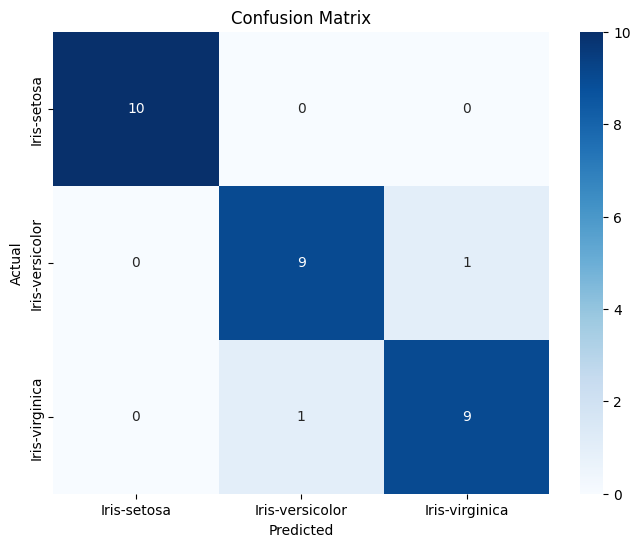

In [ ]:
y_pred = dt_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.2f}")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=dt_classifier.classes_, yticklabels=dt_classifier.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# File 2

from google.colab import files
uploaded = files.upload()

Saving drug.csv to drug.csv


In [ ]:
drug_df = pd.read_csv('/content/drug.csv')
display(drug_df.head())

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


In [ ]:
print(drug_df.info())

categorical_cols = ['Sex', 'BP', 'Cholesterol']

drug_df_encoded = pd.get_dummies(drug_df, columns=categorical_cols, drop_first=True)
display(drug_df_encoded.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB
None


,Age,Na_to_K,Drug,Sex_M,BP_LOW,BP_NORMAL,Cholesterol_NORMAL
0,23,25.355,drugY,False,False,False,False
1,47,13.093,drugC,True,True,False,False
2,47,10.114,drugC,True,True,False,False
3,28,7.798,drugX,False,False,True,False
4,61,18.043,drugY,False,True,False,False


In [ ]:
X_drug = drug_df_encoded.drop('Drug', axis=1)
y_drug = drug_df_encoded['Drug']

print("Features (X_drug) shape:", X_drug.shape)
print("Target (y_drug) shape:", y_drug.shape)

Features (X_drug) shape: (200, 6)
Target (y_drug) shape: (200,)


In [ ]:
X_train_drug, X_test_drug, y_train_drug, y_test_drug = train_test_split(X_drug, y_drug, test_size=0.2, random_state=42, stratify=y_drug)

print("X_train_drug shape:", X_train_drug.shape)
print("X_test_drug shape:", X_test_drug.shape)
print("y_train_drug shape:", y_train_drug.shape)
print("y_test_drug shape:", y_test_drug.shape)

X_train_drug shape: (160, 6)
X_test_drug shape: (40, 6)
y_train_drug shape: (160,)
y_test_drug shape: (40,)


In [ ]:
dt_classifier_drug = DecisionTreeClassifier(random_state=42)
dt_classifier_drug.fit(X_train_drug, y_train_drug)

print("Decision Tree Classifier for drug.csv trained successfully.")

Decision Tree Classifier for drug.csv trained successfully.


Accuracy Score (drug.csv): 0.97


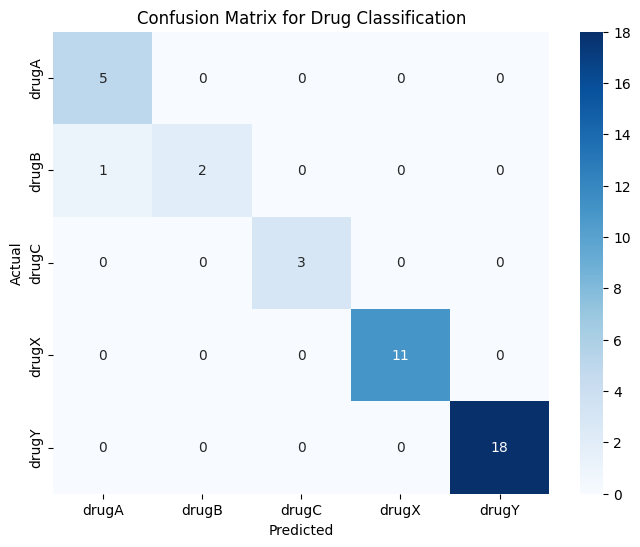

In [ ]:
y_pred_drug = dt_classifier_drug.predict(X_test_drug)

accuracy_drug = accuracy_score(y_test_drug, y_pred_drug)
print(f"Accuracy Score (drug.csv): {accuracy_drug:.2f}")

cm_drug = confusion_matrix(y_test_drug, y_pred_drug)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_drug, annot=True, fmt='d', cmap='Blues', xticklabels=dt_classifier_drug.classes_, yticklabels=dt_classifier_drug.classes_)
plt.title('Confusion Matrix for Drug Classification')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# File 3

from google.colab import files
uploaded = files.upload()

Saving petrol_consumption.csv to petrol_consumption.csv


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor # Using Regressor for regression task
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # Regression metrics
import numpy as np # For RMSE calculation

In [ ]:
petrol_df = pd.read_csv('/content/petrol_consumption.csv')

display(petrol_df.head())
print(petrol_df.info())

,Petrol_tax,Average_income,Paved_Highways,Population_Driver_licence(%),Petrol_Consumption
0,9.0,3571,1976,0.525,541
1,9.0,4092,1250,0.572,524
2,9.0,3865,1586,0.580,561
3,7.5,4870,2351,0.529,414
4,8.0,4399,431,0.544,410


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 5 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Petrol_tax                    48 non-null     float64
 1   Average_income                48 non-null     int64  
 2   Paved_Highways                48 non-null     int64  
 3   Population_Driver_licence(%)  48 non-null     float64
 4   Petrol_Consumption            48 non-null     int64  
dtypes: float64(2), int64(3)
memory usage: 2.0 KB
None


In [ ]:
X_petrol = petrol_df.drop('Petrol_Consumption', axis=1)
y_petrol = petrol_df['Petrol_Consumption']

print("Features (X_petrol) shape:", X_petrol.shape)
print("Target (y_petrol) shape:", y_petrol.shape)

Features (X_petrol) shape: (48, 4)
Target (y_petrol) shape: (48,)


In [ ]:
X_train_petrol, X_test_petrol, y_train_petrol, y_test_petrol = train_test_split(X_petrol, y_petrol, test_size=0.2, random_state=42)

print("X_train_petrol shape:", X_train_petrol.shape)
print("X_test_petrol shape:", X_test_petrol.shape)
print("y_train_petrol shape:", y_train_petrol.shape)
print("y_test_petrol shape:", y_test_petrol.shape)

X_train_petrol shape: (38, 4)
X_test_petrol shape: (10, 4)
y_train_petrol shape: (38,)
y_test_petrol shape: (10,)


In [ ]:
dt_regressor_petrol = DecisionTreeRegressor(random_state=42)
dt_regressor_petrol.fit(X_train_petrol, y_train_petrol)

print("Decision Tree Regressor for petrol_consumption.csv trained successfully.")

Decision Tree Regressor for petrol_consumption.csv trained successfully.


In [ ]:
y_pred_petrol = dt_regressor_petrol.predict(X_test_petrol)

mae_petrol = mean_absolute_error(y_test_petrol, y_pred_petrol)
print(f"Mean Absolute Error (petrol_consumption.csv): {mae_petrol:.2f}")

mse_petrol = mean_squared_error(y_test_petrol, y_pred_petrol)
print(f"Mean Squared Error (petrol_consumption.csv): {mse_petrol:.2f}")

rmse_petrol = np.sqrt(mse_petrol)
print(f"Root Mean Squared Error (petrol_consumption.csv): {rmse_petrol:.2f}")

r2_petrol = r2_score(y_test_petrol, y_pred_petrol)
print(f"R-squared (petrol_consumption.csv): {r2_petrol:.2f}")

Mean Absolute Error (petrol_consumption.csv): 94.30
Mean Squared Error (petrol_consumption.csv): 17347.70
Root Mean Squared Error (petrol_consumption.csv): 131.71
R-squared (petrol_consumption.csv): -1.59
